# Support vector Machines

Support Vector Machines (SVM) is a `supervised machine learning algorithm` which can be used for both classification or regression challenges.

However,  it is mostly used in classification problems.

In this algorithm, we plot each data item as a point in n-dimensional space (where n is number of features you have) with the value of each feature being the value of a particular coordinate. Then, we perform classification by finding the hyper-plane that differentiate the two classes very well (look at the below snapshot).

Types of SVM kernels:

1. Linear Kernel
2. Polynomial Kernel
3. Radial Basis Function Kernel (RBF)

----
# SVR
Support Vector Machine can also be used as a regression method, maintaining all the main features that characterize the algorithm (maximal margin).

### Assighnment:
ap nay support vector regroser ko use kirna ha for regression problem on aney dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
df = pd.read_csv('/content/breast-cancer.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [13]:
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
510,91550,B,11.740,14.69,76.31,426.0,0.08099,0.09661,0.067260,0.026390,...,12.450,17.60,81.25,473.8,0.10730,0.27930,0.269000,0.10560,0.2604,0.09879
232,88203002,B,11.220,33.81,70.79,386.8,0.07780,0.03574,0.004967,0.006434,...,12.360,41.78,78.44,470.9,0.09994,0.06885,0.023180,0.03002,0.2911,0.07307
2,84300903,M,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.197400,0.127900,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.450400,0.24300,0.3613,0.08758
538,921092,B,7.729,25.49,47.98,178.8,0.08098,0.04878,0.000000,0.000000,...,9.077,30.92,57.17,248.0,0.12560,0.08340,0.000000,0.00000,0.3058,0.09938
309,893548,B,13.050,13.84,82.71,530.6,0.08352,0.03735,0.004559,0.008829,...,14.730,17.40,93.96,672.4,0.10160,0.05847,0.018240,0.03532,0.2107,0.06580
135,868202,M,12.770,22.47,81.72,506.3,0.09055,0.05761,0.047110,0.027040,...,14.490,33.37,92.04,653.6,0.14190,0.15230,0.217700,0.09331,0.2829,0.08067
147,86973701,B,14.950,18.77,97.84,689.5,0.08138,0.11670,0.090500,0.035620,...,16.250,25.47,107.10,809.7,0.09970,0.25210,0.250000,0.08405,0.2852,0.09218
280,8912049,M,19.160,26.60,126.20,1138.0,0.10200,0.14530,0.192100,0.096640,...,23.720,35.90,159.80,1724.0,0.17820,0.38410,0.575400,0.18720,0.3258,0.09720
58,857810,B,13.050,19.31,82.61,527.2,0.08060,0.03789,0.000692,0.004167,...,14.230,22.25,90.24,624.1,0.10210,0.06191,0.001845,0.01111,0.2439,0.06289
471,9113816,B,12.040,28.14,76.85,449.9,0.08752,0.06000,0.023670,0.023770,...,13.600,33.33,87.24,567.6,0.10410,0.09726,0.055240,0.05547,0.2404,0.06639


In [14]:

df.drop(columns=['id'], inplace=True)

# Convert target variable 'diagnosis' to numeric (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [15]:
# Check for missing values
print(df.isnull().sum().sum())  # Should be 0 if clean


0


In [16]:
X = df.drop('diagnosis', axis=1)  # Features
y = df['diagnosis']               # Target

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = SVC(kernel='linear')  # You can also try 'rbf', 'poly', 'sigmoid'  try these to improve confusion matrix
model.fit(X_train_scaled, y_train)


SVC(kernel='linear')

In [21]:
y_pred = model.predict(X_test_scaled)


In [22]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Confusion Matrix:
[[68  3]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Accuracy Score:
0.956140350877193


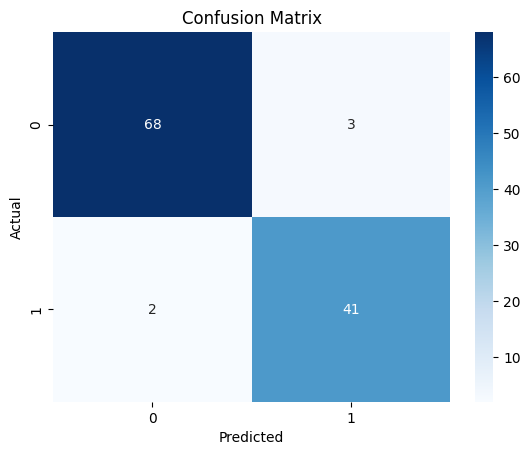

In [23]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
